# Movie Analytics Pipeline

A Python data project that transforms raw iPhone Notes movie logs into structured datasets and performs behavioral analysis using Pandas.

## 1. Data Ingestion

Loading raw movie logs from a text file exported from iPhone Notes.

In [1]:
import pandas as pd
import re

with open("data/movies_raw.txt", "r") as f:
    lines = f.readlines()


## 2. Data Parsing

Using regex and string extraction to convert raw text logs into structured movie records.

In [2]:
data = []

for line in lines:
    line = line.strip()

    if line == "":
        continue

    parts = line.split(" - ", 1)

    if len(parts) != 2:
        continue

    date = parts[0]
    rest = parts[1]

    matches = re.findall(r"\((\d+)\)", rest)

    if len(matches) < 2:
        continue

    rating = int(matches[0])
    watch_number = int(matches[1])

    title = re.sub(r"\(\d+\)\s*\(\d+\)", "", rest).strip()

    data.append([date, title, rating, watch_number])

## 3. Data Structuring

Creating a structured Pandas DataFrame and formatting columns for analysis.

In [3]:
df = pd.DataFrame(
    data,
    columns=["date", "title", "rating", "watch_number"]
)

df["date"] = pd.to_datetime(df["date"], format="%m-%d-%y")

df["year"] = df["date"].dt.year

df.head()

,date,title,rating,watch_number,year
0,2025-01-03,It’s what’s inside,6,1,2025
1,2025-01-08,phantasm II,6,2,2025
2,2025-01-08,rear window,7,3,2025
3,2025-01-10,phantasm III,2,4,2025
4,2025-01-11,self reliance,5,5,2025


## 4. Data Validation

Inspecting the dataset structure and verifying column data types.

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 129 entries, 0 to 128
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   date          129 non-null    datetime64[us]
 1   title         129 non-null    str           
 2   rating        129 non-null    int64         
 3   watch_number  129 non-null    int64         
 4   year          129 non-null    int32         
dtypes: datetime64[us](1), int32(1), int64(2), str(1)
memory usage: 4.7 KB


## 5. Exploratory Data Analysis

Analyzing movie ratings and viewing behavior trends over time.

In [5]:
df.sort_values("rating", ascending=False).head(10)

,date,title,rating,watch_number,year
17,2025-02-26,Dallas buyers club,9,18,2025
99,2025-12-31,Marty supreme,9,100,2025
33,2025-05-29,bring her back,9,34,2025
123,2026-04-20,ready or not,8,23,2026
27,2025-04-11,warfare,8,28,2025
42,2025-07-13,one flew over the cuckoos nest,8,43,2025
51,2025-08-15,Chinatown,8,52,2025
32,2025-05-15,"the good, the bad and the ugly",8,33,2025
8,2025-01-30,companion,8,9,2025
87,2025-12-09,memories of murder,8,88,2025


In [6]:
df.groupby("year")["rating"].mean()

year
2025    5.495050
2026    5.785714
Name: rating, dtype: float64

In [7]:
df.groupby("year")["title"].count().rename("movies_watched")

year
2025    101
2026     28
Name: movies_watched, dtype: int64

In [8]:
df = df.sort_values("date")

df["rolling_avg_rating"] = df["rating"].rolling(5).mean()

df[["date", "rating", "rolling_avg_rating"]].head(15)

,date,rating,rolling_avg_rating
0,2025-01-03,6,NaN
1,2025-01-08,6,NaN
2,2025-01-08,7,NaN
3,2025-01-10,2,NaN
4,2025-01-11,5,5.2
5,2025-01-20,4,4.8
6,2025-01-26,7,5.0
7,2025-01-28,7,5.0
8,2025-01-30,8,6.2
9,2025-02-02,6,6.4


## 6. Key Insights

- Built a full ETL pipeline from raw text movie logs to structured dataset
- Analyzed viewing habits across time and ratings
- Identified top-rated films and yearly trends
- Engineered time-based features including rolling averages

## Rolling Average Visualization

Line chart showing rating trends over time using a rolling average window.

<Axes: title={'center': 'Rolling Average Movie Ratings'}, xlabel='date'>

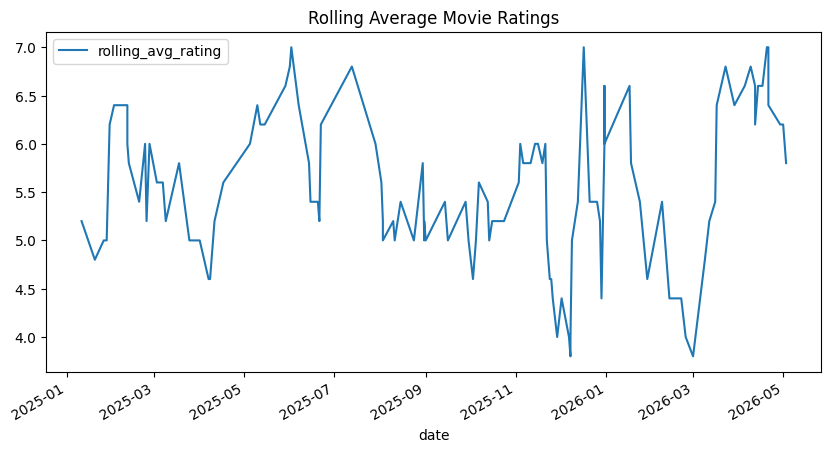

In [9]:
df.plot(
    x="date",
    y="rolling_avg_rating",
    figsize=(10,5),
    title="Rolling Average Movie Ratings"
)